In [57]:
# Install required libraries
!pip install kagglehub polars pyarrow pandas numpy matplotlib seaborn


# Abstract

This study investigates what factors affect an online gamer's anxiety level, using the Online Gaming Anxiety dataset of over 13,000 survey responses collected from gaming communities. After filtering to League of Legends players and cleaning the data (handling nulls, outliers, and inconsistent text categories), we explore anxiety (`GAD_T`) alongside social anxiety (`SPIN_T`), life satisfaction (`SWL_T`), and weekly hours played (`Hours`). Initial exploratory analysis shows anxiety scores are right-skewed and moderately correlated with social anxiety and life satisfaction, but only weakly related to hours played. These early findings will guide the next phase of statistical testing and modeling.

# Dataset Description

### General Description

The Online Gaming Anxiety Dataset is a large-scale public dataset compiled by researchers __Marian Sauter__ and __Dejan Draschkow__ (2017). It was designed to empirically investigate the relationship between online video gaming behaviors (e.g., playtimes, social contexts, motivations) and mental health indicators—specifically generalized anxiety, social phobia, and overall life satisfaction.

### How the Dataset was Collected

- __Method:__ The researchers used an _online survey/questionnaire_ hosted on the Open Science Framework (OSF)

- __Recruitment:__ Convenience sampling was employed by posting invitations containing the links to the survey across online gaming communities and forums such as `r/gaming`, `r/leagueoflegends`.

### Potential Implications of Data Collection on Generated Insights

- **Self-Selection Bias:** Voluntary participation may have attracted gamers with strong opinions or higher psychological distress.
- **Community Bias:** Recruitment through gaming forums likely overrepresents hardcore/competitive players and underrepresents casual or mobile-first gamers.
- **Self-Reporting Bias:** Playtime and stream-watching hours are self-reported and may be inaccurately estimated; psychological scores may carry social desirability bias.
- **No Control Group:** Since only active gamers were surveyed, there is no non-gamer baseline for comparison.

These biases mean conclusions apply mainly to active, forum-engaged gamers, not gamers in general.

### Structure of the Data

- __Representation__
> - __Rows:__ Each row represents a single, anonymous response.
> - __Columns:__ Each column respresents a specific attribute including demographics, gaming behaviors, or an aggregated clinical scale.

- __Number of Observations__
> - __Original Dataset:__ Contains `13,464` entries across `55` columns.
> - __Cleaned Dataset:__ Contains `10k+` entries across `19` standardized columns after dropping metadata, individual questionnaire items, null values, and outliers with weekly playtime `>100 hours`.

### Attribute Dictionary

**1. Demographic Attributes**
- `Age:` Numeric, respondent's age (18-56 years).
- `Gender:` Categorical, gender identity (Male, Female, Other).
- `Degree:` Categorical, highest educational attainment.
- `Work:` Categorical, employment status (Employed, Unemployed, Student).
- `Birthplace` & `Residence:` Categorical, country of birth and current residence.

**2. Gaming Behavior & Motivation Attributes**
- `Hours:` Numeric, average weekly hours playing (max 100).
- `streams:` Numeric, average weekly hours watching game streams.
- `Platform:` Categorical, primary gaming system (PC, Console, Mobile).
- `Playstyle:` Categorical, social setting of play (solo, with online/offline friends, strangers).
- `League:` Categorical, competitive rank tier (Master+ to Bronze, Unranked).
- `whyplay:` Categorical, main reason for playing (fun, improving, winning, relaxing, escapism, other).
- `earnings:` Categorical, plays for fun vs. financial compensation.
- `Game:` Categorical, primary game played.

**3. Clinical & Psychological Attributes (Aggregated)**
- `GAD_T:` Numeric, total GAD-7 anxiety score (0-21; higher = more anxious).
- `SWL_T:` Numeric, total life satisfaction score, SWLS scale (5-35; higher = more satisfied).
- `SPIN_T:` Numeric, total social anxiety score, SPIN scale (0-68; higher = more severe).
- `GADE:` Categorical, how much anxiety affects daily life/work.
- `Narcissism:` Numeric, self-reported single-item score (1-5).

Individual item-level columns (`GAD1-7`, `SWL1-5`, `SPIN1-17`) were dropped in favor of these totals.

## Import required modules and download csv file.

In [58]:
import kagglehub
import polars as pl
import os
path = kagglehub.dataset_download("divyansh22/online-gaming-anxiety-data")

print("Path to dataset files:", path)
csv = os.path.join(path, "GamingStudy_data.csv")
df = pl.read_csv(csv, encoding="latin1", null_values="NA")

Path to dataset files: C:\Users\jlgfd\.cache\kagglehub\datasets\divyansh22\online-gaming-anxiety-data\versions\3


# Data Cleaning and Preprocessing

In [59]:
pl.Config.set_tbl_rows(-1)        # Show all rows
pl.Config.set_tbl_cols(-1)        # Show all columns
pl.Config.set_tbl_width_chars(-1) # Use full terminal width
df.describe()

statistic,S. No.,Timestamp,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,SWL1,SWL2,SWL3,SWL4,SWL5,Game,Platform,Hours,earnings,whyplay,League,highestleague,streams,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Gender,Age,Work,Degree,Birthplace,Residence,Reference,Playstyle,accept,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,str,str,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,str,str,str,str,str,str,f64,f64,f64,str,str
"""count""",13464.0,13464.0,13464.0,13464.0,13464.0,13464.0,13464.0,13464.0,13464.0,"""12815""",13464.0,13464.0,13464.0,13464.0,13464.0,"""13464""","""13464""",13434.0,"""13464""","""13464""","""11719""","""0""",13364.0,13340.0,13310.0,13324.0,13305.0,13298.0,13308.0,13326.0,13320.0,13306.0,13304.0,13277.0,13296.0,13277.0,13308.0,13317.0,13317.0,13289.0,13441.0,"""13464""",13464.0,"""13426""","""13464""","""13464""","""13464""","""13449""","""13464""","""13050""",13464.0,13464.0,12814.0,"""13354""","""13343"""
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""649""",0.0,0.0,0.0,0.0,0.0,"""0""","""0""",30.0,"""0""","""0""","""1745""","""13464""",100.0,124.0,154.0,140.0,159.0,166.0,156.0,138.0,144.0,158.0,160.0,187.0,168.0,187.0,156.0,147.0,147.0,175.0,23.0,"""0""",0.0,"""38""","""0""","""0""","""0""","""15""","""0""","""414""",0.0,0.0,650.0,"""110""","""121"""
"""mean""",7096.839201,42054.841222,0.860963,0.673351,0.965761,0.724079,0.488042,0.911022,0.588755,null,3.72044,4.60205,4.34544,3.762032,3.358883,null,null,22.247357,null,null,null,null,11.233538,0.856897,1.210969,1.095392,1.682976,1.248985,1.348287,1.050503,1.40503,1.567338,0.917769,1.827446,0.892148,0.538827,1.252405,1.411054,0.620635,0.935962,2.027677,null,20.930407,null,null,null,null,null,null,null,5.211973,19.788844,19.848525,null,null
"""std""",4114.47822,0.272948,0.926542,0.915724,0.982776,0.921971,0.837014,0.931168,0.894408,null,1.736264,1.696276,1.80943,1.818136,1.916319,null,null,70.284502,null,null,null,null,78.549209,0.907351,1.144054,1.164982,1.22973,1.221828,1.279251,1.221171,1.372777,1.383539,1.125849,1.488372,1.158235,0.94418,1.207463,1.349874,0.961853,1.180456,1.061842,null,3.300897,null,null,null,null,null,null,null,4.713267,7.229243,13.467493,null,null
"""min""",1.0,42052.00437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Extremely difficult""",1.0,1.0,1.0,1.0,1.0,"""Counter Strike""","""Console (PS, Xbox, ...)""",0.0,""" play for fun at the moment, b…","""1. Having fun 2. winning 3. im…",""" """,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"""Female""",18.0,"""Employed""","""Bachelor (or equivalent)""","""Afghanistan""","""Albania""","""CrowdFlower""",""" Multiplayer - online - with f…","""Accept""",0.0,5.0,0.0,"""ALB""","""AFG"""
"""25%""",3533.0,42054.71655,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,2.0,3.0,3.0,2.0,2.0,null,null,12.0,null,null,null,null,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,null,18.0,null,null,null,null,null,null,null,2.0,14.0,9.0,null,null
"""50%""",7088.0,42054.80069,1.0,0.0,1.0,0.0,0.0,1.0,0.0,null,4.0,5.0,5.0,4.0,3.0,null,null,20.0,null,null,null,null,8.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,null,20.0,null,null,null,null,null,null,null,4.0,20.0,17.0,null,null
"""75%""",10654.0,42054.93211,1.0,1.0,2.0,1.0,1.0,1.0,1.0,null,5.0,6.0,6.0,5.0,5.0,null,null,28.0,null,null,null,null,15.0,1.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,3.0,1.0,3.0,1.0,1.0,2.0,2.0,1.0,2.0,3.0,null,22.0,null,null,null,null,null,null,null,8.0,26.0,28.0,null,null
"""max""",14250.0,42058.36375,3.0,3.0,3.0,3.0,3.0,3.0,3.0,"""Very difficult""",7.0,7.0,7.0,7.0,7.0,"""World of Warcraft""","""Smartphone / Tablet""",8000.0,"""working towards getting some f…","""winning/improving/and having f…","""~plat""",null,9001.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0

## Drop Unnecessary Columns
These columns were dropped as this study will utilize the aggregate variables rather than individual questionnaire items:
- `S. No.` & `Timestamp` (not useful for statistical modeling)
- `GAD1` to `GAD7` (redundant, represented by the total score `GAD_T`)
- `SWL1` to `SWL5` (redundant, represented by `SWL_T`)
- `SPIN1` to `SPIN17` (redundant, represented by `SPIN_T`)
- `highestleague` (100% null/missing values)
- `Residence_ISO3` & `Birthplace_ISO3` (redundant, represented by `Residence` and `Birthplace` respectively)
- `accept` (participant consent column, contains no predictive information for modeling)
- `reference` (contains no predictive information for modeling)

In [60]:
dropped_columns = [
    "S. No.", "Timestamp", "GAD1", "GAD2", "GAD3", "GAD4", "GAD5", "GAD6", "GAD7",
    "SWL1", "SWL2", "SWL3", "SWL4", "SWL5", "SPIN1", "SPIN2", "SPIN3", "SPIN4",
    "SPIN5", "SPIN6", "SPIN7", "SPIN8", "SPIN9", "SPIN10", "SPIN11", "SPIN12",
    "SPIN13", "SPIN14", "SPIN15", "SPIN16", "SPIN17", "highestleague",
    "Residence_ISO3", "Birthplace_ISO3", "accept", "Reference"
]

df_clean = df.drop(dropped_columns)
df_clean.head()
df_clean["Game"].value_counts()

Game,count
str,u32
"""Starcraft 2""",345
"""Skyrim""",28
"""World of Warcraft""",152
"""League of Legends""",11314
"""Hearthstone""",101
"""Diablo 3""",89
"""Counter Strike""",318
"""Other""",1021
"""Heroes of the Storm""",41


## Scoping Down to League of Legends Players
Since this study will only consider league of legends players. We filter out everybody else.

In [61]:
df_clean = df_clean.filter(pl.col("Game") == "League of Legends")

## Outlier Treatment

Drop unrealistic values in the `Hours` column (participants reporting >=100 hours of gaming per week).

In [62]:
df_clean["Hours"].describe()

statistic,value
str,f64
"""count""",11291.0
"""null_count""",23.0
"""mean""",22.185457
"""std""",76.272326
"""min""",0.0
"""25%""",12.0
"""50%""",20.0
"""75%""",28.0
"""max""",8000.0


In [63]:
df_clean = df_clean.filter(pl.col("Hours") < 100)
df_clean.shape

(11270, 19)

### Streams Outlier Treatment

We apply the same `>=100` hours/week threshold to `streams` (weekly hours watching game streams). The uncleaned maximum of 168 hours — equivalent to watching streams 24 hours a day, 7 days a week — is physically impossible and likely represents data entry errors or joke responses.

In [64]:
df_clean = df_clean.filter(pl.col("streams") < 100)
df_clean.shape

(11191, 19)

## Null Cleaning
Each column was checked for null values. Whether to drop or impute nulls was decided based on the proportion and nature of the missingness.

In [65]:
df_clean.null_count()

GADE,Game,Platform,Hours,earnings,whyplay,League,streams,Narcissism,Gender,Age,Work,Degree,Birthplace,Residence,Playstyle,GAD_T,SWL_T,SPIN_T
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
530,0,0,0,0,0,1149,0,18,0,0,32,0,0,0,0,0,0,534


### Null Value Imputation and Dropping

1. **GADE (How gaming affects daily life/work)**: The `GADE` question is optional in the official GAD questionnaire and is skipped if the participant has zero anxiety. Therefore, we impute missing `GADE` values as `"Not difficult at all"` if `GAD_T == 0`. The remaining null values for `GADE` (where `GAD_T > 0`) are dropped.
2. **Other Nulls**: We drop rows containing null values for `Narcissism`, `streams`, `Work`, and `SPIN_T` as they represent a small percentage of the dataset.

In [66]:
# Impute GADE as 'Not difficult at all' when GAD_T is 0
df_clean = df_clean.with_columns(
    pl.when(pl.col("GADE").is_null() & (pl.col("GAD_T") == 0))
    .then(pl.lit("Not difficult at all"))
    .otherwise(pl.col("GADE"))
    .alias("GADE")
)

# Drop remaining nulls across key columns
df_clean = df_clean.drop_nulls(["Narcissism", "streams", "Work", "GADE", "SPIN_T"])
df_clean.shape

(10580, 19)

*Take note the "Work" column includes unemployed, students and employment so there's no valid reason to have it as null*

## Standardizing the League and whyplay Columns

The `League` and `whyplay` columns are free-text fields containing typos and inconsistent entries, so we standardize them into discrete categories.

#### League Rank Standardization
- **Master+:** Challenger, Master, Grandmaster, GM, and typos (e.g. *challenjour*).
- **Diamond:** Diamond, Dia, abbreviations (*d1*-*d5*).
- **Platinum:** Platinum, Plat, and misspellings.
- **Gold:** Gold and typos (*glod*, *golld*).
- **Silver:** Silver and misspellings (*sliver*, *siver*).
- **Bronze:** Bronze and misspellings (*bronce*, *broze*).
- **Unranked:** Blank/unranked responses, non-League ranks, and noise.

In [67]:
df_clean = df_clean.with_columns(pl.col("whyplay").str.to_lowercase())
df_clean = df_clean.with_columns(pl.col("League").str.to_lowercase())

In [68]:
# Apply simplified Polars mapping expressions
league_lower = pl.col("League").fill_null("unranked").str.to_lowercase()

df_clean = df_clean.with_columns(
    pl.when(league_lower.str.contains(r"unranked|unrank"))
    .then(pl.lit("Unranked"))
    .when(league_lower.str.contains(r"bronze|\bb[1-5]\b"))
    .then(pl.lit("Bronze"))
    .when(league_lower.str.contains(r"silver|\bs[1-5]\b"))
    .then(pl.lit("Silver"))
    .when(league_lower.str.contains(r"gold|\bg[1-5]\b"))
    .then(pl.lit("Gold"))
    .when(league_lower.str.contains(r"platinum|plat|\bp[1-5]\b"))
    .then(pl.lit("Platinum"))
    .when(league_lower.str.contains(r"diamond|dia|\bd[1-5]\b"))
    .then(pl.lit("Diamond"))
    .when(league_lower.str.contains(r"master|grandmaster|challenger|gm"))
    .then(pl.lit("Master+"))
    .otherwise(pl.lit("Unranked"))
    .alias("League_Standardized")
)

**Note on Rank Standardization Logic:**
We standardize by **current rank** rather than peak rank, as current rank is a more relevant factor for measuring active anxiety. To implement this:
1. We check for **Unranked first**. Players often list their historical peak rank followed by a statement that they are currently unranked (e.g., *"Diamond 5 S4, currently unranked"*). Checking for "unranked" first ensures they are correctly classified under their current status.
2. We evaluate actual ranks from **lowest to highest** (Bronze to Master+). This ensures that if a player lists both a lower current rank and a higher previous peak rank (e.g., *"Bronze 2, was Gold 5"*), the matching logic evaluates the lower league first, correctly standardizing them to their current rank.

#### whyplay (Reason for Playing) Standardization
- **Having Fun:** Joy, pleasure, fun-related motivations.
- **Improving:** Skill progression and learning.
- **Winning:** Competition, victory, rank-climbing.
- **Relaxing:** De-stressing, casual play.
- **Mixed / All:** Custom responses citing multiple reasons.
- **Escapism:** Passing time, distraction from reality.
- **Other:** Custom/uncategorized answers.

In [69]:

# Standardize whyplay
wp_lower = pl.col("whyplay").fill_null("other").str.to_lowercase()

has_fun = wp_lower.str.contains("fun")
has_improv = wp_lower.str.contains("improv")
has_win = wp_lower.str.contains("win")
has_relax = wp_lower.str.contains("relax")
has_escapism = wp_lower.str.contains("escap|distract|forget|time")

is_mixed = wp_lower.str.contains("all|both|mix") | (
    (has_fun.cast(pl.Int32) + has_improv.cast(pl.Int32) + has_win.cast(pl.Int32) + has_relax.cast(pl.Int32)) > 1
)

df_clean = df_clean.with_columns(
    pl.when(is_mixed)
    .then(pl.lit("Mixed / All"))
    .when(has_fun)
    .then(pl.lit("Having Fun"))
    .when(has_improv)
    .then(pl.lit("Improving"))
    .when(has_win)
    .then(pl.lit("Winning"))
    .when(has_relax)
    .then(pl.lit("Relaxing"))
    .when(has_escapism)
    .then(pl.lit("Escapism"))
    .otherwise(pl.lit("Other"))
    .alias("whyplay_Standardized")
)

print(df_clean.select(["League", "League_Standardized"]).head(5))
print(df_clean.select(["whyplay", "whyplay_Standardized"]).head(5))

shape: (5, 2)
┌────────────────────┬─────────────────────┐
│ League             ┆ League_Standardized │
│ ---                ┆ ---                 │
│ str                ┆ str                 │
╞════════════════════╪═════════════════════╡
│ gold               ┆ Gold                │
│ bronze             ┆ Bronze              │
│ silver 4           ┆ Silver              │
│ gold               ┆ Gold                │
│ unranked - low elo ┆ Unranked            │
└────────────────────┴─────────────────────┘
shape: (5, 2)
┌────────────┬──────────────────────┐
│ whyplay    ┆ whyplay_Standardized │
│ ---        ┆ ---                  │
│ str        ┆ str                  │
╞════════════╪══════════════════════╡
│ having fun ┆ Having Fun           │
│ having fun ┆ Having Fun           │
│ improving  ┆ Improving            │
│ having fun ┆ Having Fun           │
│ improving  ┆ Improving            │
└────────────┴──────────────────────┘


Write to files for independent checks

In [70]:
# Save original vs standardized column mappings to an editable text file
with pl.Config(tbl_rows=-1, fmt_str_lengths=1000, tbl_width_chars=10000):
    league_mapping = str(df_clean.group_by(["League", "League_Standardized"]).len().sort("len", descending=True))
    whyplay_mapping = str(df_clean.group_by(["whyplay", "whyplay_Standardized"]).len().sort("len", descending=True))

# Drop the original columns as they won't be needed anymore
df_clean.drop_in_place("League")
df_clean.drop_in_place("whyplay")

with open("standardization_output.txt", "w", encoding="utf-8") as f:
    f.write("=== ORIGINAL LEAGUE vs STANDARDIZED LEAGUE ===\n")
    f.write(league_mapping)
    f.write("\n\n=== ORIGINAL WHYPLAY vs STANDARDIZED WHYPLAY ===\n")
    f.write(whyplay_mapping)

# Save aggregate (overall distribution) of standardized columns to a separate file
with pl.Config(tbl_rows=-1, fmt_str_lengths=1000, tbl_width_chars=10000):
    league_aggregate = str(df_clean["League_Standardized"].value_counts(sort=True))
    whyplay_aggregate = str(df_clean["whyplay_Standardized"].value_counts(sort=True))

with open("standardization_aggregate.txt", "w", encoding="utf-8") as f:
    f.write("=== AGGREGATE STANDARDIZED LEAGUE COUNTS ===\n")
    f.write(league_aggregate)
    f.write("\n\n=== AGGREGATE STANDARDIZED WHYPLAY COUNTS ===\n")
    f.write(whyplay_aggregate)

## Final Preprocessed Data

In [71]:
df_clean.describe()

statistic,GADE,Game,Platform,Hours,earnings,streams,Narcissism,Gender,Age,Work,Degree,Birthplace,Residence,Playstyle,GAD_T,SWL_T,SPIN_T,League_Standardized,whyplay_Standardized
str,str,str,str,f64,str,f64,f64,str,f64,str,str,str,str,str,f64,f64,f64,str,str
"""count""","""10580""","""10580""","""10580""",10580.0,"""10580""",10580.0,10580.0,"""10580""",10580.0,"""10580""","""10580""","""10580""","""10580""","""10580""",10580.0,10580.0,10580.0,"""10580""","""10580"""
"""null_count""","""0""","""0""","""0""",0.0,"""0""",0.0,0.0,"""0""",0.0,"""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0"""
"""mean""",null,null,null,21.245274,null,10.456616,2.022117,null,20.834499,null,null,null,null,null,5.184026,19.849622,19.739319,null,null
"""std""",null,null,null,12.839585,null,9.758833,1.058137,null,3.155653,null,null,null,null,null,4.668667,7.18406,13.380982,null,null
"""min""","""Extremely difficult""","""League of Legends""","""Console (PS, Xbox, ...)""",0.0,""" play for fun at the moment, b…",0.0,1.0,"""Female""",18.0,"""Employed""","""Bachelor (or equivalent)""","""Afghanistan""","""Albania""",""" Multiplayer - online - with f…",0.0,5.0,0.0,"""Bronze""","""Escapism"""
"""25%""",null,null,null,12.0,null,4.0,1.0,null,18.0,null,null,null,null,null,2.0,14.0,9.0,null,null
"""50%""",null,null,null,20.0,null,8.0,2.0,null,20.0,null,null,null,null,null,4.0,20.0,17.0,null,null
"""75%""",null,null,null,28.0,null,15.0,3.0,null,22.0,null,null,null,null,null,8.0,26.0,28.0,null,null
"""max""","""Very difficult""","""League of Legends""","""Smartphone / Tablet""",96.0,"""working towards getting some f…",90.0,5.0,"""Other""",56.0,"""Unemployed / between jobs""","""Ph.D., Psy. D., MD (or equival…","""Zimbabwe""","""Vietnam""","""with strangers and with my fri…",21.0,35.0,68.0,"""Unranked""","""Winning"""


# Research Question & Exploratory Data Analysis

## General Research Question

**What factors affect an online gamer's anxiety level (`GAD_T`)?**

This question was approved by our instructor and was deliberately kept broad rather than narrowed to a single variable pair, since it warrants exploring multiple demographic, behavioral, and psychological variables instead of just one relationship. It is answerable from this dataset because `GAD_T` and plausible related variables (`SPIN_T`, `SWL_T`, `Hours`) are all directly measured. We expect to refine this question further as our EDA and later statistical testing progress.

## setup Polars to Pandas

In [72]:
import pyarrow as pa
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

df_pd = df_clean.to_pandas()

numeric_cols = ["Hours", "GAD_T", "SPIN_T", "SWL_T"]

print("Dataset Shape:", df_pd.shape)
df_pd[numeric_cols].head()

Dataset Shape: (10580, 19)


,Hours,GAD_T,SPIN_T,SWL_T
0,25,0,3,33
1,5,5,31,26
2,9,0,39,26
3,7,1,29,21
4,25,11,17,10


### EDA Question 1: How is anxiety severity distributed among League of Legends players?

We start by summarizing the central tendency and spread of `GAD_T`, alongside related variables `Hours`, `SPIN_T`, and `SWL_T`, to understand typical anxiety levels before looking at relationships between variables.

## Measures of Central Tendency

In [73]:
# Mean
mean_values = df_pd[numeric_cols].mean()
print("MEAN VALUES\n", mean_values)

# Median
median_values = df_pd[numeric_cols].median()
print("\nMEDIAN VALUES\n", median_values)



MEAN VALUES
 Hours     21.245274
GAD_T      5.184026
SPIN_T    19.739319
SWL_T     19.849622
dtype: float64

MEDIAN VALUES
 Hours     20.0
GAD_T      4.0
SPIN_T    17.0
SWL_T     20.0
dtype: float64


,count,mean,std,min,25%,50%,75%,max
Hours,10580.0,21.245274,12.839585,0.0,12.0,20.0,28.0,96.0
GAD_T,10580.0,5.184026,4.668667,0.0,2.0,4.0,8.0,21.0
SPIN_T,10580.0,19.739319,13.380982,0.0,9.0,17.0,28.0,68.0
SWL_T,10580.0,19.849622,7.184060,5.0,14.0,20.0,26.0,35.0


**Interpretation:** The mean `GAD_T` score is about 5.19, while the median is 4. Since the mean exceeds the median, the anxiety distribution is right-skewed: most players report low-to-moderate anxiety, but a smaller group reports much higher scores, pulling the average up.

Using the standard GAD-7 clinical severity bands (0–4 = minimal, 5–9 = mild, 10–14 = moderate, 15–21 = severe), the **median of 4** places the typical League of Legends player right at the upper edge of *minimal* anxiety. However, the **mean of ~5.2** being pulled above the mild-anxiety threshold suggests a meaningful tail of moderate-to-severe cases in the sample.

### Visualization (distribution check)

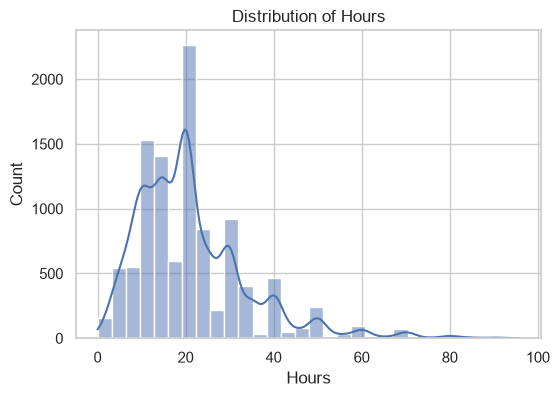

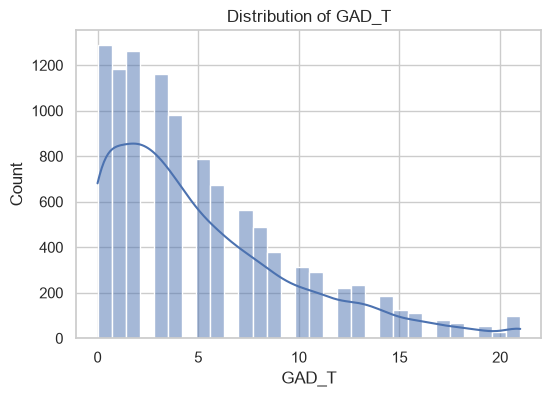

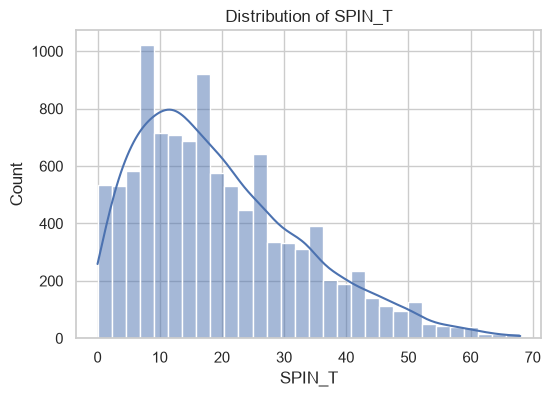

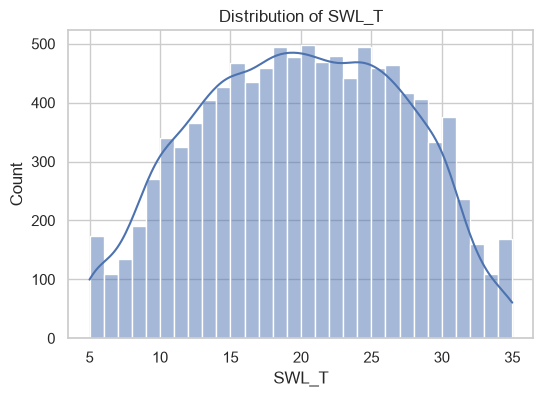

In [74]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_pd[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

**Interpretation:** The histogram confirms the right skew in `GAD_T` — most players cluster at low anxiety scores, with a long tail toward higher scores. Notably, the **peak at 0** means a substantial proportion of players report *no anxiety symptoms at all*. `SPIN_T` shows a similar right-skewed pattern, while `SWL_T` is closer to symmetric — consistent with life satisfaction being a more normally distributed trait in general populations. `Hours` is also right-skewed with a long tail of high-playtime outliers.

### EDA Question 2: How much do anxiety, social anxiety, and life satisfaction scores vary, and are there extreme cases?

Here we examine dispersion (standard deviation, variance) and use boxplots to spot outliers and the spread of scores across players.

## Measures of Dispersion

In [75]:
# Standard deviation
std_values = df_pd[numeric_cols].std()
print("STANDARD DEVIATION\n", std_values)

# Variance
var_values = df_pd[numeric_cols].var()
print("\nVARIANCE\n", var_values)

STANDARD DEVIATION
 Hours     12.839585
GAD_T      4.668667
SPIN_T    13.380982
SWL_T      7.184060
dtype: float64

VARIANCE
 Hours     164.854950
GAD_T      21.796455
SPIN_T    179.050670
SWL_T      51.610714
dtype: float64


**Interpretation:** `GAD_T` has a standard deviation of about 4.67 on a 0–21 scale, showing considerable spread. One standard deviation above the mean (~9.9) already falls in the **moderate anxiety** band (10–14), implying that roughly 16% of the sample may have moderate-or-worse anxiety.

`SPIN_T` is even more spread out (std ~13.39 on a 0–68 scale). Importantly, the SPIN clinical cutoff for social phobia is 19 — and our sample mean (~19.7) sits *right at* that threshold, suggesting that social anxiety is remarkably prevalent among League of Legends players.

`SWL_T` is comparatively tighter (std ~7.19 on a 5–35 scale) — life satisfaction scores cluster more closely than anxiety-related scores.

### Boxplot

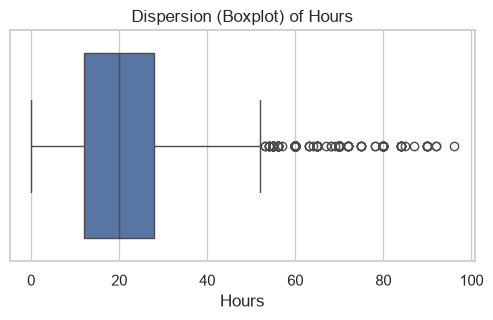

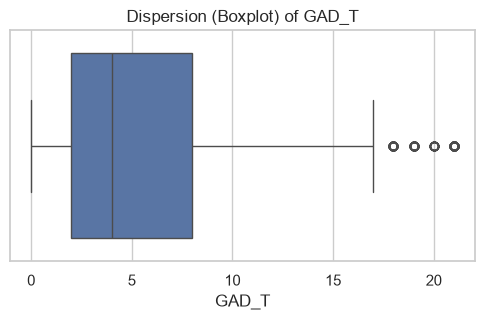

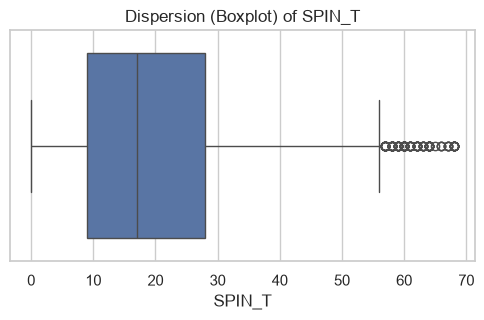

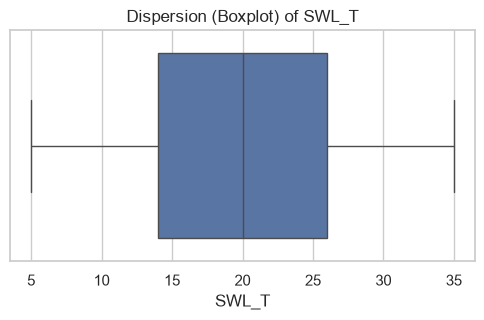

In [76]:
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df_pd[col])
    plt.title(f"Dispersion (Boxplot) of {col}")
    plt.show()

**Interpretation:** The boxplots show `GAD_T` and `SPIN_T` both have upper-tail outliers — a subset of players reporting unusually high anxiety and social anxiety. `Hours` has the most extreme outliers, consistent with a few players reporting very high weekly playtime even after removing values of 100+ hours.

### EDA Question 3: Is anxiety associated with social anxiety, life satisfaction, or hours played?

To explore possible factors behind anxiety, we compute correlations between `GAD_T` and the other numeric variables, using both Pearson (linear) and Spearman (rank-based) measures to check robustness.

### Pearson Correlation (Linear Relationship)

PEARSON CORRELATION

           Hours     GAD_T    SPIN_T     SWL_T
Hours   1.000000  0.092208  0.095674 -0.129773
GAD_T   0.092208  1.000000  0.452977 -0.396411
SPIN_T  0.095674  0.452977  1.000000 -0.313438
SWL_T  -0.129773 -0.396411 -0.313438  1.000000


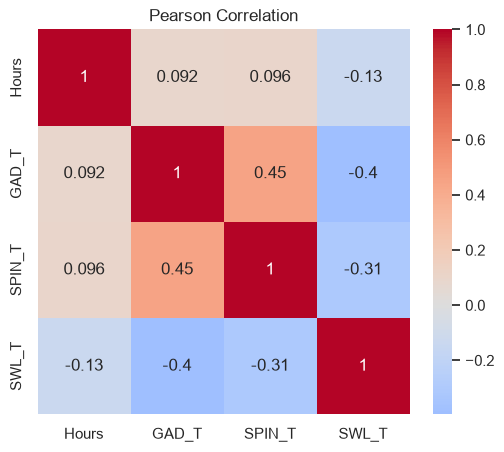

In [78]:
pearson_corr = df_pd[numeric_cols].corr(method="pearson")
print("PEARSON CORRELATION\n")
print(pearson_corr)

plt.figure(figsize=(6,5))
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Pearson Correlation")
plt.show()

**Interpretation:** Under Pearson correlation, `GAD_T` shows a moderate positive linear relationship with `SPIN_T` (0.45) and a moderate negative linear relationship with `SWL_T` (-0.40). The relationship with `Hours` is negligible (0.09).

### Spearman Correlation (Rank-based Relationship)

SPEARMAN CORRELATION

           Hours     GAD_T    SPIN_T     SWL_T
Hours   1.000000  0.065056  0.086839 -0.116681
GAD_T   0.065056  1.000000  0.434009 -0.390630
SPIN_T  0.086839  0.434009  1.000000 -0.305714
SWL_T  -0.116681 -0.390630 -0.305714  1.000000


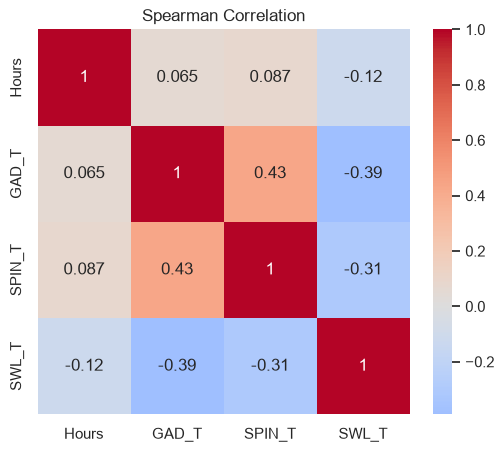

In [79]:
spearman_corr = df_pd[numeric_cols].corr(method="spearman")
print("SPEARMAN CORRELATION\n")
print(spearman_corr)

plt.figure(figsize=(6,5))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman Correlation")
plt.show()

**Interpretation:** Spearman correlations are close to the Pearson values (e.g. `GAD_T`-`SPIN_T`: 0.43 vs 0.45), indicating these relationships are fairly monotonic and not driven by a few extreme outliers or strong nonlinearity.

### Pearson vs Spearman Comparison

In [80]:
comparison = pd.DataFrame({
    "Pearson": df_pd[numeric_cols].corr(method="pearson").unstack(),
    "Spearman": df_pd[numeric_cols].corr(method="spearman").unstack()
})

print(comparison)

                Pearson  Spearman
Hours  Hours   1.000000  1.000000
       GAD_T   0.092208  0.065056
       SPIN_T  0.095674  0.086839
       SWL_T  -0.129773 -0.116681
GAD_T  Hours   0.092208  0.065056
       GAD_T   1.000000  1.000000
       SPIN_T  0.452977  0.434009
       SWL_T  -0.396411 -0.390630
SPIN_T Hours   0.095674  0.086839
       GAD_T   0.452977  0.434009
       SPIN_T  1.000000  1.000000
       SWL_T  -0.313438 -0.305714
SWL_T  Hours  -0.129773 -0.116681
       GAD_T  -0.396411 -0.390630
       SPIN_T -0.313438 -0.305714
       SWL_T   1.000000  1.000000


**Interpretation:** Since Pearson and Spearman values are consistently close across all pairs, the linear correlation estimates appear reliable. This answers EDA Question 3: social anxiety and life satisfaction appear more strongly associated with anxiety than weekly hours played, making them the most promising factors for further statistical testing.

### EDA Question 4: Do anxiety levels differ across player demographics and behaviors?

Having examined the overall distribution and spread of anxiety scores, we now investigate whether `GAD_T` varies meaningfully across key categorical variables. This will help identify the most promising group-level predictors of anxiety.

#### GAD_T by Gender

C:\Users\jlgfd\AppData\Local\Temp\ipykernel_16632\837653669.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pd, x="Gender", y="GAD_T",


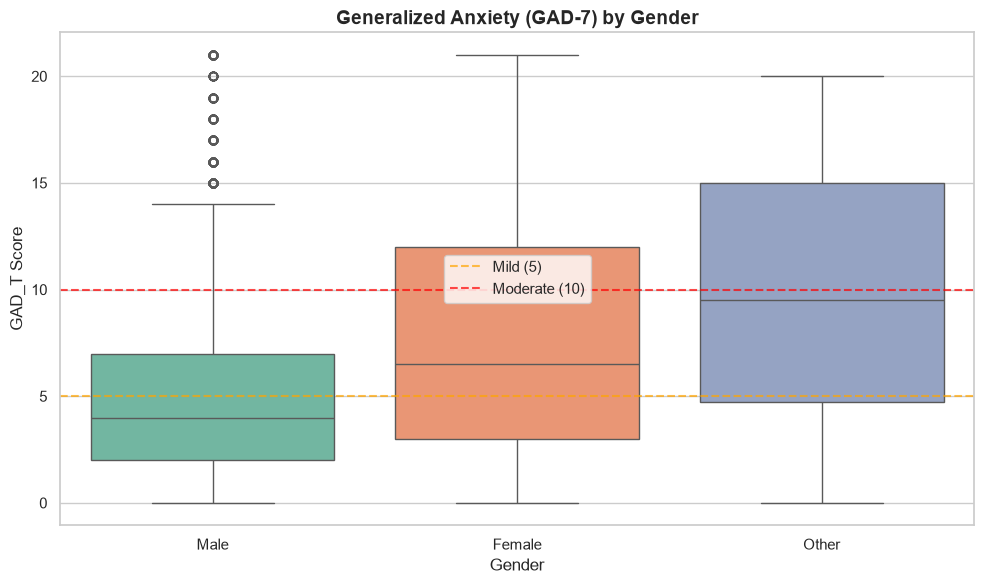


Group summary:
        count  mean  median   std
Gender                           
Female    574  7.61     6.5  5.55
Male     9974  5.03     4.0  4.56
Other      32  9.78     9.5  5.83


In [81]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_pd, x="Gender", y="GAD_T",
            order=["Male", "Female", "Other"], palette="Set2", ax=ax)
ax.set_title("Generalized Anxiety (GAD-7) by Gender",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Gender", fontsize=12)
ax.set_ylabel("GAD_T Score", fontsize=12)
ax.axhline(y=5, color="orange", linestyle="--", alpha=0.7, label="Mild (5)")
ax.axhline(y=10, color="red", linestyle="--", alpha=0.7, label="Moderate (10)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nGroup summary:")
print(df_pd.groupby("Gender")["GAD_T"]
      .agg(["count", "mean", "median", "std"]).round(2))

**Interpretation:** The sample is overwhelmingly male (n=9,974), with far fewer female (n=574) and other-gender (n=32) respondents. Despite the imbalance, clear differences emerge: **female players report notably higher anxiety** (mean 7.61, median 6.5) compared to male players (mean 5.03, median 4.0). The Other group shows the highest scores (mean 9.78, median 9.5), though this group is too small for reliable inference. The gender gap is substantial -- female players' mean anxiety is roughly 51% higher than males', and their median falls in the *mild* clinical range (5-9) versus males' *minimal* range (0-4).

#### GAD_T by Competitive Rank (League)

C:\Users\jlgfd\AppData\Local\Temp\ipykernel_16632\2095768199.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pd, x="League_Standardized", y="GAD_T",


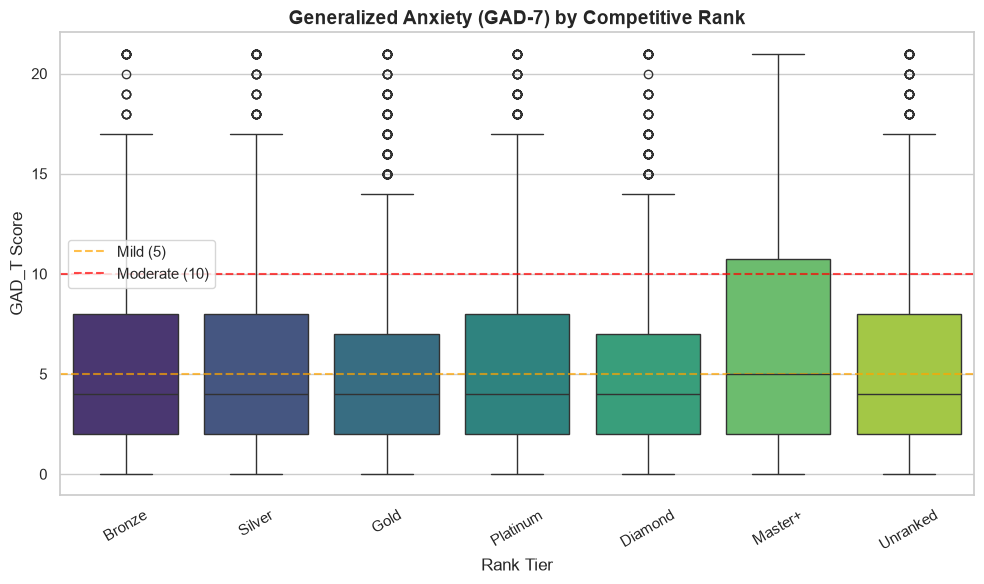


Group summary:
                     count  mean  median   std
League_Standardized                           
Bronze                 472  5.69     4.0  5.11
Silver                1978  5.37     4.0  4.71
Gold                  2668  4.90     4.0  4.47
Platinum              2236  5.17     4.0  4.59
Diamond               1295  5.06     4.0  4.66
Master+                138  6.78     5.0  5.92
Unranked              1793  5.26     4.0  4.75


In [82]:
rank_order = ["Bronze", "Silver", "Gold", "Platinum",
              "Diamond", "Master+", "Unranked"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_pd, x="League_Standardized", y="GAD_T",
            order=rank_order, palette="viridis", ax=ax)
ax.set_title("Generalized Anxiety (GAD-7) by Competitive Rank",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Rank Tier", fontsize=12)
ax.set_ylabel("GAD_T Score", fontsize=12)
ax.axhline(y=5, color="orange", linestyle="--", alpha=0.7, label="Mild (5)")
ax.axhline(y=10, color="red", linestyle="--", alpha=0.7, label="Moderate (10)")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("\nGroup summary:")
print(df_pd.groupby("League_Standardized")["GAD_T"]
      .agg(["count", "mean", "median", "std"])
      .reindex(rank_order).round(2))

**Interpretation:** Anxiety levels are fairly consistent across most rank tiers, with medians of 4.0 for Bronze through Diamond and Unranked. The notable exception is **Master+ players, who show the highest mean anxiety (6.78) and a median of 5.0**, placing them in the *mild* clinical range. Bronze players also trend slightly higher (mean 5.69). Gold players have the lowest mean (4.90). The relatively flat pattern across Silver-Diamond suggests that rank alone is not a strong predictor, but the elevated anxiety at the highest competitive tier may reflect the greater pressure and time investment at that level.

#### GAD_T by Reason for Playing

C:\Users\jlgfd\AppData\Local\Temp\ipykernel_16632\2536895826.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pd, x="whyplay_Standardized", y="GAD_T",


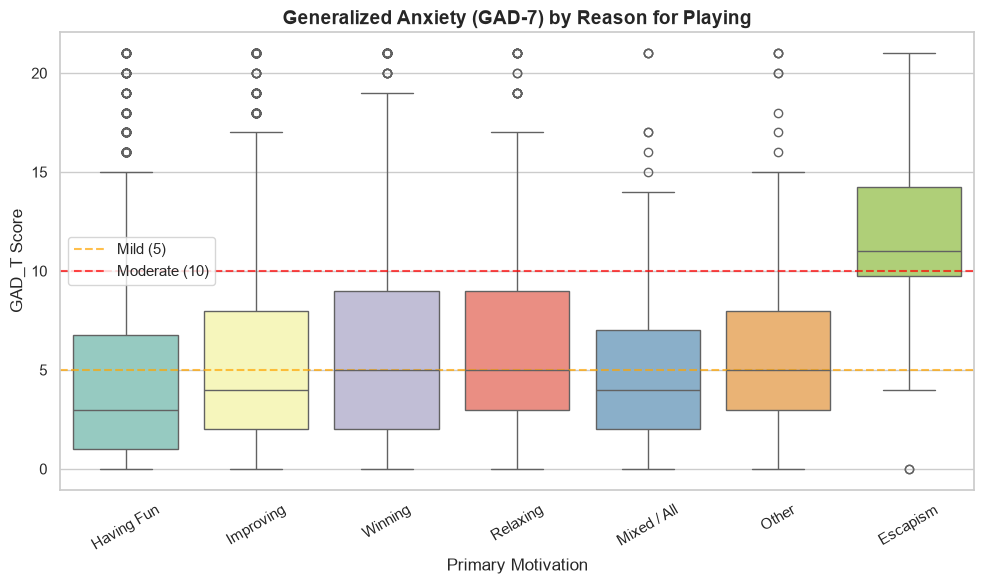


Group summary:
                      count   mean  median   std
whyplay_Standardized                            
Escapism                 24  11.04    11.0  5.15
Having Fun             4102   4.53     3.0  4.37
Improving              3990   5.25     4.0  4.55
Mixed / All             258   4.66     4.0  4.11
Other                    77   6.64     5.0  5.57
Relaxing                449   6.41     5.0  5.12
Winning                1680   6.22     5.0  5.20


In [83]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_pd, x="whyplay_Standardized", y="GAD_T",
            palette="Set3", ax=ax)
ax.set_title("Generalized Anxiety (GAD-7) by Reason for Playing",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Primary Motivation", fontsize=12)
ax.set_ylabel("GAD_T Score", fontsize=12)
ax.axhline(y=5, color="orange", linestyle="--", alpha=0.7, label="Mild (5)")
ax.axhline(y=10, color="red", linestyle="--", alpha=0.7, label="Moderate (10)")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("\nGroup summary:")
print(df_pd.groupby("whyplay_Standardized")["GAD_T"]
      .agg(["count", "mean", "median", "std"]).round(2))

**Interpretation:** This is the strongest categorical signal in the dataset. 
**Players who cite Escapism have dramatically higher anxiety** (mean 11.04, median 11.0) 
compared to every other group -- more than double the Having Fun group (mean 4.53, median 3.0). 
The Escapism median of 11.0 falls squarely in the *moderate* clinical range (10-14), 
while Having Fun players sit in the *minimal* range. 
**However, it is crucial to note that the Escapism group is extremely small (n=24)** compared 
to groups like Having Fun (n=4,102). While the effect size is large, this limits the robustness 
of the finding. Winning (mean 6.22) and Relaxing (mean 6.41) also show elevated anxiety relative 
to Having Fun, while Mixed/All players (mean 4.66) resemble the Having Fun group. 
Overall, this suggests that **motivation for playing is a meaningful predictor of anxiety**, 
but the extremes (like Escapism) require further validation with larger samples.

#### GAD_T by Employment Status

C:\Users\jlgfd\AppData\Local\Temp\ipykernel_16632\2028334827.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pd, x="Work", y="GAD_T",


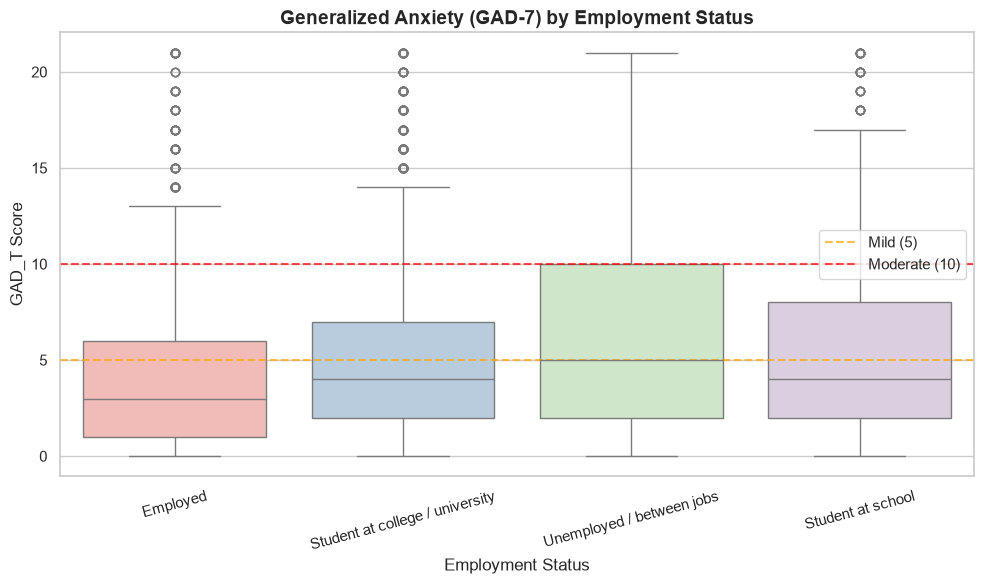


Group summary:
                                 count  mean  median   std
Work                                                      
Employed                          2109  4.51     3.0  4.46
Student at college / university   5690  5.15     4.0  4.56
Student at school                 1753  5.40     4.0  4.67
Unemployed / between jobs         1028  6.35     5.0  5.36


In [84]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_pd, x="Work", y="GAD_T",
            palette="Pastel1", ax=ax)
ax.set_title("Generalized Anxiety (GAD-7) by Employment Status",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Employment Status", fontsize=12)
ax.set_ylabel("GAD_T Score", fontsize=12)
ax.axhline(y=5, color="orange", linestyle="--", alpha=0.7, label="Mild (5)")
ax.axhline(y=10, color="red", linestyle="--", alpha=0.7, label="Moderate (10)")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nGroup summary:")
print(df_pd.groupby("Work")["GAD_T"]
      .agg(["count", "mean", "median", "std"]).round(2))

**Interpretation:** A clear gradient appears across employment status. **Unemployed players report the highest anxiety** (mean 6.35, median 5.0), followed by school students (mean 5.40), college students (mean 5.15), and employed players (mean 4.51, median 3.0). The gap between unemployed and employed is 1.84 points on the GAD-7 scale, moving from the *minimal* to the *mild* clinical band. While employment status may be confounded with age (students are typically younger), the pattern is consistent with the known link between unemployment and anxiety in the general population.

## EDA Summary & Implications

### Key Findings

1. **Anxiety is right-skewed:** Most League of Legends players report minimal-to-mild anxiety (`GAD_T` median = 4, mean = 5.18) based on standard GAD-7 clinical cutoffs (Spitzer et al., 2006), but a meaningful minority has moderate-to-severe scores. The distribution is not normal.
2. **Social anxiety is highly prevalent:** The mean `SPIN_T` (~19.7) sits right at the clinical cutoff for social phobia (19) established by Connor et al. (2000), suggesting that social anxiety is remarkably common in this gaming community.
3. **Life satisfaction is roughly symmetric:** `SWL_T` shows the most normal-like distribution among the clinical variables, with scores centering around the midpoint of the scale.
4. **Motivation is a strong categorical predictor:** Players citing Escapism report dramatically higher anxiety (mean 11.04) than Having Fun players (mean 4.53) -- a difference of over 6 points on the GAD-7 scale. However, the Escapism sample is very small (n=24), meaning this extreme result should be interpreted with caution.
5. **Gender and employment status show clear gradients:** Female and other-gender players, as well as unemployed players, report higher anxiety than their counterparts.
6. **Rank has a mostly flat relationship with anxiety**, except at the Master+ tier (mean 6.78), which may reflect elevated competitive pressure.
7. **Playtime has a weak relationship with anxiety:** `Hours` shows only a modest correlation with `GAD_T`, suggesting that *how much* someone plays is less important than *why* they play.

### Implications for Further Analysis

- **The right-skew of `GAD_T` suggests non-parametric tests** (e.g., Kruskal-Wallis, Mann-Whitney U) or transformations may be needed for group comparisons.
- **Strong candidates for statistical testing:**
  - `SPIN_T` vs. `GAD_T` (regression): the moderate positive correlation between social anxiety and generalized anxiety is the strongest numeric signal.
  - `SWL_T` vs. `GAD_T` (regression): the negative correlation between life satisfaction and anxiety.
  - `whyplay_Standardized` vs. `GAD_T` (ANOVA/Kruskal-Wallis): does motivation explain anxiety differences?
  - `Work` vs. `GAD_T` (ANOVA/Kruskal-Wallis): does employment status matter?
- **The weak `Hours` vs. `GAD_T` relationship is itself a meaningful null result** worth formally testing.

# References
- *[Kaggle Dataset Link](https://www.kaggle.com/datasets/divyansh22/online-gaming-anxiety-data/data)*
- *[Original Paper](https://osf.io/preprints/psyarxiv/mfajz_v1)*
- *[Questionnaire](https://osf.io/vnbxk/files/vyr5f?view_only=4c54da075e164ea2a5329f5669d03c41)*
- Connor, K. M., et al. (2000). Psychometric properties of the Social Phobia Inventory (SPIN). *The British Journal of Psychiatry*, 176(4), 379-386.
- Spitzer, R. L., Kroenke, K., Williams, J. B., & Löwe, B. (2006). A brief measure for assessing generalized anxiety disorder: the GAD-7. *Archives of internal medicine*, 166(10), 1092-1097.
